# 1. IMPORTATION DES BIBLIOTHEQUES  

In [97]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# 2. CHARGEMENT DES DONNEES Mpox RDC.csv 

In [98]:
df_mpox = pd.read_csv("donnees_mpox_RDC_3000.csv")
df_mpox


,ID,Semaine,Province,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Saison,Population_Risque,Taux_Positivite_pct
0,OBS_00001,1,Mongala,206,24.4,0.480,64,39,31.8,150,22,1,4,29,Pluie,3478,19.33
1,OBS_00002,2,Kinshasa,56,23.7,0.474,74,107,24.9,300,5,1,6,42,Seche,3713,14.00
2,OBS_00003,3,Kinshasa,59,25.2,0.333,62,140,53.9,310,16,0,8,20,Seche,4833,6.45
3,OBS_00004,4,Mai-Ndombe,396,24.1,0.354,68,97,25.9,210,4,0,10,82,Pluie,3777,39.05
4,OBS_00005,5,Kasaï,127,19.8,0.303,61,86,30.3,260,24,1,6,24,Pluie,9396,9.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,OBS_02996,2996,Kongo Central,271,31.6,0.534,88,57,22.4,220,33,1,7,125,Pluie,3166,56.82
2996,OBS_02997,2997,Sud-Ubangi,88,24.6,0.262,95,47,34.1,370,7,1,6,70,Seche,6099,18.92
2997,OBS_02998,2998,Bas-Uele,268,25.6,0.720,58,18,41.9,190,23,0,2,36,Pluie,5475,18.95
2998,OBS_02999,2999,Haut-Uele,211,24.9,0.196,77,28,10.6,370,2,0,2,160,Pluie,4813,43.24


# 3.EXPLORATION DES DONNEES 

## 3.1. Dimensions de la base des données 

In [99]:
df_mpox.shape


(3000, 17)

##  Interprétation 
 
La base de données utilisée dans cette étude comprend 3000 observations décrivant les cas confirmés de Mpox ainsi que plusieurs facteurs susceptibles d'influencer leur évolution, notamment les conditions climatiques, environnementales, démographiques et sanitaires. Cette quantité importante d'informations permet d'obtenir des résultats plus fiables et représentatifs. En tant que décideur, vous pouvez avoir davantage confiance dans les conclusions issues de cette analyse, car elles reposent sur un nombre élevé d'observations plutôt que sur quelques cas isolés. Ces résultats peuvent ainsi servir de base pour orienter les politiques de surveillance et les interventions de santé publique.

## 3.2. Aperçu des données 

In [100]:
print("Aperçu des données épidémiologiques :")
print(df_mpox.head(10))

Aperçu des données épidémiologiques :
          ID  Semaine       Province  Pluviometrie_mm  Temperature_C   NDVI  \
0  OBS_00001        1        Mongala              206           24.4  0.480   
1  OBS_00002        2       Kinshasa               56           23.7  0.474   
2  OBS_00003        3       Kinshasa               59           25.2  0.333   
3  OBS_00004        4     Mai-Ndombe              396           24.1  0.354   
4  OBS_00005        5          Kasaï              127           19.8  0.303   
5  OBS_00006        6        Tshuapa              400           20.6  0.721   
6  OBS_00007        7  Kongo Central              181           26.6  0.779   
7  OBS_00008        8         Kwango              356           22.9  0.607   
8  OBS_00009        9         Tshopo              252           30.3  0.527   
9  OBS_00010       10          Kwilu               27           22.1  0.608   

   Humidite_pct  Densite_Population  Couverture_Vaccinale_pct  Tests_Realises  \
0          

## Interprétation 

L'examen des premières lignes de la base de données confirme que les informations nécessaires à l'analyse sont correctement enregistrées. Chaque observation contient les variables essentielles permettant d'étudier les liens entre les facteurs environnementaux, les caractéristiques de la population et les cas confirmés de Mpox. Cela signifie que les analyses réalisées reposent sur une base de données suffisamment structurée pour soutenir les décisions opérationnelles.

## 3.3. Types des variables 

In [101]:
df_mpox.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        3000 non-null   object 
 1   Semaine                   3000 non-null   int64  
 2   Province                  3000 non-null   object 
 3   Pluviometrie_mm           3000 non-null   int64  
 4   Temperature_C             3000 non-null   float64
 5   NDVI                      3000 non-null   float64
 6   Humidite_pct              3000 non-null   int64  
 7   Densite_Population        3000 non-null   int64  
 8   Couverture_Vaccinale_pct  3000 non-null   float64
 9   Tests_Realises            3000 non-null   int64  
 10  Distance_Centre_Sante_km  3000 non-null   int64  
 11  Reservoirs_Animaux        3000 non-null   int64  
 12  Mobilite_Humaine          3000 non-null   int64  
 13  Cas_Confirmes             3000 non-null   int64  
 14  Saison  

## Interprétation 

Les données regroupent plusieurs catégories d'informations : des variables climatiques (pluviométrie, température, humidité), environnementales (NDVI), démographiques (densité de population), sanitaires (couverture vaccinale, nombre de tests réalisés) ainsi que des informations géographiques. Cette diversité permet d'avoir une vision globale des facteurs pouvant influencer la propagation de la Mpox. Pour les décideurs, ceci revient à dire que les actions de lutte contre la maladie ne doivent pas se limiter au secteur de la santé, mais intégrer également les facteurs environnementaux et les caractéristiques des populations exposées.

## 3.4. Statistiques descriptives 

In [102]:
print("\nStatistiques descriptives :")
print(df_mpox.describe())


Statistiques descriptives :
           Semaine  Pluviometrie_mm  Temperature_C         NDVI  Humidite_pct  \
count  3000.000000      3000.000000    3000.000000  3000.000000   3000.000000   
mean   1500.500000       157.779667      24.980367     0.451182     71.571667   
std     866.169729       101.958774       3.832510     0.157799     11.625285   
min       1.000000         2.000000      18.000000     0.103000     40.000000   
25%     750.750000        77.000000      22.300000     0.331000     64.000000   
50%    1500.500000       136.000000      24.900000     0.452000     71.500000   
75%    2250.250000       221.000000      27.600000     0.576000     80.000000   
max    3000.000000       400.000000      34.000000     0.795000     95.000000   

       Densite_Population  Couverture_Vaccinale_pct  Tests_Realises  \
count         3000.000000               3000.000000     3000.000000   
mean           119.100333                 31.843967      286.143333   
std             95.218460   

# 4. PRETRAITEMENT DES DONNEES 

# 4.1. Suppression de la varaiable ID  

In [103]:
# Suppression de la variable ID

df_mpox = df_mpox.drop(columns=['ID'])

# Nous le supprimons car ça n'apporte aucune information sur notre modèle 

## Interprétation 

La variable ID a été supprimée de l'analyse, car elle sert uniquement à identifier les observations et n'apporte aucune information utile pour expliquer les cas confirmés de Mpox. Cette étape permet au modèle de se concentrer uniquement sur les facteurs ayant un véritable intérêt pour la prise de décision.

In [104]:
# Vérifier que la variable a bien été supprimée

df_mpox.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Semaine                   3000 non-null   int64  
 1   Province                  3000 non-null   object 
 2   Pluviometrie_mm           3000 non-null   int64  
 3   Temperature_C             3000 non-null   float64
 4   NDVI                      3000 non-null   float64
 5   Humidite_pct              3000 non-null   int64  
 6   Densite_Population        3000 non-null   int64  
 7   Couverture_Vaccinale_pct  3000 non-null   float64
 8   Tests_Realises            3000 non-null   int64  
 9   Distance_Centre_Sante_km  3000 non-null   int64  
 10  Reservoirs_Animaux        3000 non-null   int64  
 11  Mobilite_Humaine          3000 non-null   int64  
 12  Cas_Confirmes             3000 non-null   int64  
 13  Saison                    3000 non-null   object 
 14  Populati

# 4.2. Valeurs manquantes 

In [105]:
# Valeurs manquantes

df_mpox.isnull().sum()


Semaine                     0
Province                    0
Pluviometrie_mm             0
Temperature_C               0
NDVI                        0
Humidite_pct                0
Densite_Population          0
Couverture_Vaccinale_pct    0
Tests_Realises              0
Distance_Centre_Sante_km    0
Reservoirs_Animaux          0
Mobilite_Humaine            0
Cas_Confirmes               0
Saison                      0
Population_Risque           0
Taux_Positivite_pct         0
dtype: int64

## Interprétation 

Aucune valeur manquante n'a été identifiée dans la base de données. Cela constitue un point important, car toutes les analyses ont été réalisées sur des informations complètes. Les résultats obtenus sont donc moins susceptibles d'être influencés par des erreurs liées à l'absence de données. 

# 4.3. Doublons 

In [106]:
# Vérifications des doublons

df_mpox.duplicated().sum()
 

np.int64(0)

## Interprétation 

L'analyse montre qu'aucun doublon n'est présent dans la base de données. Chaque observation correspond donc à une situation unique. Cette qualité des données réduit le risque de surestimer ou de sous-estimer certains phénomènes et renforce la crédibilité des résultats.

# 4.4. Encodages 

In [107]:
# Encodage des variables qualitatives (Province et Saison)

df_mpox = pd.get_dummies(
    df_mpox,
    columns=["Province", "Saison"],
    drop_first=True
)

In [108]:
df_mpox.head()

,Semaine,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,...,Province_Nord-Kivu,Province_Nord-Ubangi,Province_Sankuru,Province_Sud-Kivu,Province_Sud-Ubangi,Province_Tanganyika,Province_Tshopo,Province_Tshuapa,Province_Équateur,Saison_Seche
0,1,206,24.4,0.480,64,39,31.8,150,22,1,...,False,False,False,False,False,False,False,False,False,False
1,2,56,23.7,0.474,74,107,24.9,300,5,1,...,False,False,False,False,False,False,False,False,False,True
2,3,59,25.2,0.333,62,140,53.9,310,16,0,...,False,False,False,False,False,False,False,False,False,True
3,4,396,24.1,0.354,68,97,25.9,210,4,0,...,False,False,False,False,False,False,False,False,False,False
4,5,127,19.8,0.303,61,86,30.3,260,24,1,...,False,False,False,False,False,False,False,False,False,False


## Interprétation 

Les variables qualitatives telles que la province et la saison ont été transformées en variables numériques afin qu'elles puissent être prises en compte par le modèle de régression. Cette transformation ne modifie pas leur signification ; elle permet simplement au modèle d'évaluer leur influence sur les cas confirmés. Grâce à cette étape, il devient possible d'identifier si certaines provinces ou certaines saisons présentent un risque plus élevé que d'autres, ce qui peut aider à cibler les interventions de manière plus efficace.

In [109]:
# Identifier toutes les colonnes de type bool

bool_cols = df_mpox.select_dtypes(include='bool').columns

In [110]:
# Les convertir en entiers (0 et 1)

df_mpox[bool_cols] = df_mpox[bool_cols].astype(int)

In [111]:
df_mpox.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Semaine                   3000 non-null   int64  
 1   Pluviometrie_mm           3000 non-null   int64  
 2   Temperature_C             3000 non-null   float64
 3   NDVI                      3000 non-null   float64
 4   Humidite_pct              3000 non-null   int64  
 5   Densite_Population        3000 non-null   int64  
 6   Couverture_Vaccinale_pct  3000 non-null   float64
 7   Tests_Realises            3000 non-null   int64  
 8   Distance_Centre_Sante_km  3000 non-null   int64  
 9   Reservoirs_Animaux        3000 non-null   int64  
 10  Mobilite_Humaine          3000 non-null   int64  
 11  Cas_Confirmes             3000 non-null   int64  
 12  Population_Risque         3000 non-null   int64  
 13  Taux_Positivite_pct       3000 non-null   float64
 14  Province

## Interprétation 

Les variables issues de l'encodage ont été converties en valeurs numériques compatibles avec les méthodes statistiques utilisées. Cette opération garantit que toutes les informations sont correctement exploitées par le modèle et améliore la fiabilité des estimations obtenues.

# 5. ANALYSE EXPLORATOIRE DES DONNEES (EDA) 

In [112]:


df_mpox.describe().T


,count,mean,std,min,25%,50%,75%,max
Semaine,3000.0,1500.500000,866.169729,1.000,750.750,1500.500,2250.250,3000.000
Pluviometrie_mm,3000.0,157.779667,101.958774,2.000,77.000,136.000,221.000,400.000
Temperature_C,3000.0,24.980367,3.832510,18.000,22.300,24.900,27.600,34.000
NDVI,3000.0,0.451182,0.157799,0.103,0.331,0.452,0.576,0.795
Humidite_pct,3000.0,71.571667,11.625285,40.000,64.000,71.500,80.000,95.000
Densite_Population,3000.0,119.100333,95.218460,5.000,48.000,94.000,163.000,500.000
Couverture_Vaccinale_pct,3000.0,31.843967,14.079517,5.600,20.800,30.400,41.525,77.800
Tests_Realises,3000.0,286.143333,88.256194,90.000,220.000,280.000,340.000,800.000
Distance_Centre_Sante_km,3000.0,15.558333,15.139386,1.000,5.000,11.000,22.000,142.000
Reservoirs_Animaux,3000.0,0.400000,0.489980,0.000,0.000,0.000,1.000,1.000


In [113]:
print("Statistiques descriptives :")
print(df_mpox[['Cas_Confirmes']].describe())

Statistiques descriptives :
       Cas_Confirmes
count    3000.000000
mean       79.603333
std        70.119799
min         0.000000
25%        29.000000
50%        57.000000
75%       109.000000
max       479.000000


In [114]:
variables = [
    'Cas_Confirmes',
    'Tests_Realises',
    'Taux_Positivite_pct',
    'Pluviometrie_mm',
    'Temperature_C',
    'NDVI',
    'Humidite_pct',
    'Densite_Population',
    'Couverture_Vaccinale_pct',
    'Distance_Centre_Sante_km',
    'Population_Risque'
]

print(df_mpox[variables].describe())

       Cas_Confirmes  Tests_Realises  Taux_Positivite_pct  Pluviometrie_mm  \
count    3000.000000     3000.000000          3000.000000      3000.000000   
mean       79.603333      286.143333            27.041943       157.779667   
std        70.119799       88.256194            20.156959       101.958774   
min         0.000000       90.000000             0.000000         2.000000   
25%        29.000000      220.000000            11.430000        77.000000   
50%        57.000000      280.000000            21.455000       136.000000   
75%       109.000000      340.000000            38.070000       221.000000   
max       479.000000      800.000000            95.000000       400.000000   

       Temperature_C         NDVI  Humidite_pct  Densite_Population  \
count    3000.000000  3000.000000   3000.000000         3000.000000   
mean       24.980367     0.451182     71.571667          119.100333   
std         3.832510     0.157799     11.625285           95.218460   
min        18

## Interprétation 

Les statistiques descriptives permettent d'avoir une première vision des caractéristiques de la population étudiée et de la variabilité des différents facteurs. Elles montrent que certaines variables présentent une forte dispersion, tandis que d'autres restent relativement stables.

# 5.1. Histogrammes 

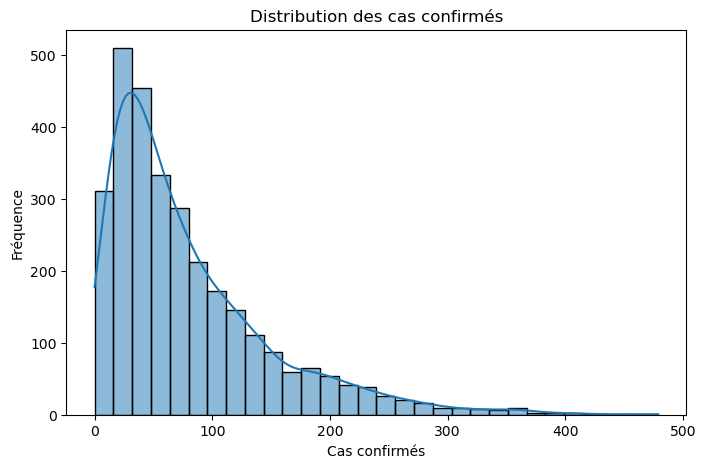

In [115]:
plt.figure(figsize=(8,5))

sns.histplot(df_mpox["Cas_Confirmes"], bins=30, kde=True)

plt.title("Distribution des cas confirmés")
plt.xlabel("Cas confirmés")
plt.ylabel("Fréquence")

plt.show()

# 5.2. Boxplots 

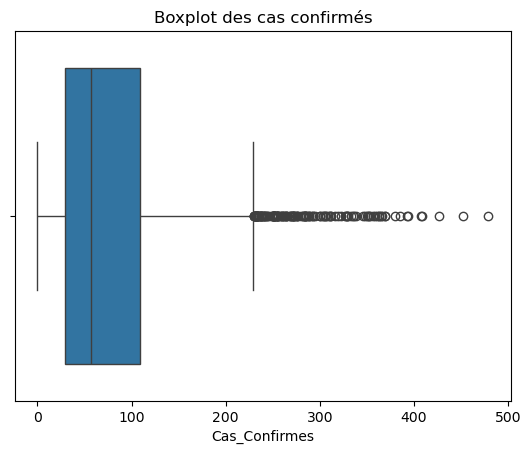

In [116]:
# 5.2. plt.figure(figsize=(7,4))

sns.boxplot(x=df_mpox["Cas_Confirmes"])

plt.title("Boxplot des cas confirmés")

plt.show() 

# 6. ANALYSE DES CORRELATIONS 

# 6.1. Matrice de corrélation 

In [117]:
corr =df_mpox.select_dtypes(
    include=np.number
).corr()

corr

,Semaine,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,...,Province_Nord-Kivu,Province_Nord-Ubangi,Province_Sankuru,Province_Sud-Kivu,Province_Sud-Ubangi,Province_Tanganyika,Province_Tshopo,Province_Tshuapa,Province_Équateur,Saison_Seche
Semaine,1.000000,0.021729,-0.003056,-0.008289,-0.004408,-0.024729,-0.006269,0.008703,-0.019993,0.011058,...,0.018640,-0.004430,-0.047236,0.004442,-0.010309,0.030578,0.010467,-0.028214,-0.021844,-0.034270
Pluviometrie_mm,0.021729,1.000000,0.026601,-0.025333,-0.017752,0.014991,-0.012357,0.001739,0.034043,-0.023265,...,0.002801,0.037307,-0.016577,0.003426,-0.009197,0.005030,-0.006984,-0.007506,-0.022039,-0.718956
Temperature_C,-0.003056,0.026601,1.000000,0.010839,0.013354,-0.015716,0.011588,-0.030491,0.007746,0.007841,...,-0.010226,0.042215,0.016368,-0.020525,-0.009561,0.025950,0.003088,-0.000574,0.000583,-0.021127
NDVI,-0.008289,-0.025333,0.010839,1.000000,-0.014116,-0.013468,0.031270,-0.041643,-0.026057,-0.011831,...,-0.004253,0.010064,0.011154,-0.002813,0.034460,-0.016580,0.003786,0.025197,0.016986,0.032965
Humidite_pct,-0.004408,-0.017752,0.013354,-0.014116,1.000000,-0.029717,0.021939,0.007457,0.001039,-0.016566,...,-0.013926,0.007286,0.031190,0.000199,0.001433,-0.016771,0.009864,-0.021624,0.005511,0.012329
Densite_Population,-0.024729,0.014991,-0.015716,-0.013468,-0.029717,1.000000,0.033371,-0.017050,0.029964,0.003835,...,-0.004572,-0.020689,-0.018626,-0.016828,-0.025487,0.004698,0.042059,0.021546,0.014530,-0.024026
Couverture_Vaccinale_pct,-0.006269,-0.012357,0.011588,0.031270,0.021939,0.033371,1.000000,-0.021319,-0.007123,-0.016166,...,-0.012704,-0.016478,0.011999,0.019300,0.004162,0.014878,-0.001133,0.011591,0.002314,0.037473
Tests_Realises,0.008703,0.001739,-0.030491,-0.041643,0.007457,-0.017050,-0.021319,1.000000,-0.020806,-0.030859,...,-0.014414,0.026291,0.014839,-0.008822,-0.011201,-0.002259,-0.012476,-0.029643,0.010537,0.018637
Distance_Centre_Sante_km,-0.019993,0.034043,0.007746,-0.026057,0.001039,0.029964,-0.007123,-0.020806,1.000000,0.007642,...,-0.007614,-0.015482,0.002425,0.001979,-0.013942,-0.005506,-0.004046,0.015013,-0.000752,-0.024640
Reservoirs_Animaux,0.011058,-0.023265,0.007841,-0.011831,-0.016566,0.003835,-0.016166,-0.030859,0.007642,1.000000,...,-0.008637,0.005468,-0.004941,0.010814,0.026284,0.003472,-0.010417,0.029893,0.014481,0.026142


## 6.2. Carte thermique  

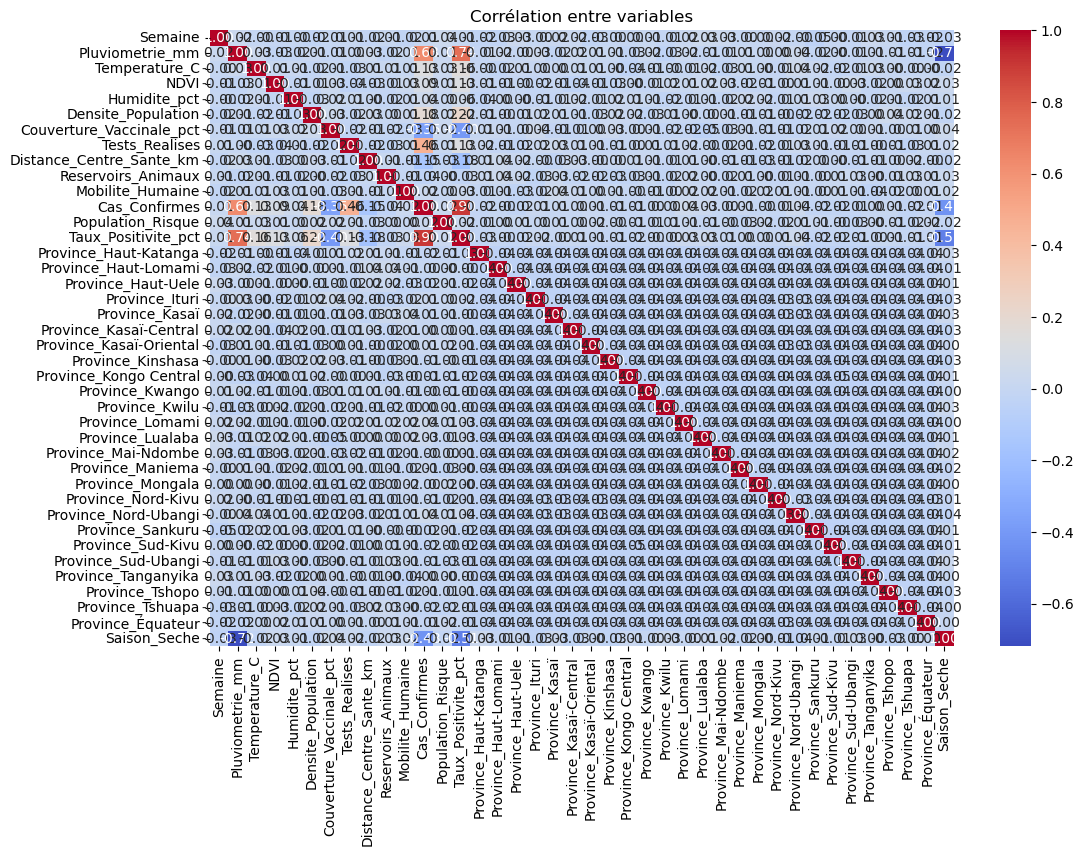

In [118]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Corrélation entre variables")
plt.show()

In [119]:
# Liste des variables clés
variables_cles = [
    "Semaine",
    "Pluviometrie_mm",
    "Temperature_C",
    "NDVI",
    "Humidite_pct",
    "Densite_Population",
    "Couverture_Vaccinale_pct",
    "Tests_Realises",
    "Distance_Centre_Sante_km",
    "Reservoirs_Animaux",
    "Mobilite_Humaine",
    "Cas_Confirmes",
    "Population_Risque",
    "Taux_Positivite_pct",
    "Saison_Seche",  # Conserve-la uniquement si tu en as besoin
]

# Matrice de corrélation restreinte
corr = df_mpox[variables_cles].corr()

corr

,Semaine,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Population_Risque,Taux_Positivite_pct,Saison_Seche
Semaine,1.000000,0.021729,-0.003056,-0.008289,-0.004408,-0.024729,-0.006269,0.008703,-0.019993,0.011058,-0.023608,0.007926,0.038807,0.009897,-0.034270
Pluviometrie_mm,0.021729,1.000000,0.026601,-0.025333,-0.017752,0.014991,-0.012357,0.001739,0.034043,-0.023265,0.010007,0.625170,0.013184,0.735529,-0.718956
Temperature_C,-0.003056,0.026601,1.000000,0.010839,0.013354,-0.015716,0.011588,-0.030491,0.007746,0.007841,0.005675,0.131251,0.025079,0.159576,-0.021127
NDVI,-0.008289,-0.025333,0.010839,1.000000,-0.014116,-0.013468,0.031270,-0.041643,-0.026057,-0.011831,0.025868,0.091674,0.013683,0.126989,0.032965
Humidite_pct,-0.004408,-0.017752,0.013354,-0.014116,1.000000,-0.029717,0.021939,0.007457,0.001039,-0.016566,0.005139,0.042544,0.001847,0.057886,0.012329
Densite_Population,-0.024729,0.014991,-0.015716,-0.013468,-0.029717,1.000000,0.033371,-0.017050,0.029964,0.003835,0.013249,0.181571,0.023336,0.218059,-0.024026
Couverture_Vaccinale_pct,-0.006269,-0.012357,0.011588,0.031270,0.021939,0.033371,1.000000,-0.021319,-0.007123,-0.016166,-0.025612,-0.350440,0.019925,-0.401540,0.037473
Tests_Realises,0.008703,0.001739,-0.030491,-0.041643,0.007457,-0.017050,-0.021319,1.000000,-0.020806,-0.030859,0.011500,0.462248,0.008702,0.125094,0.018637
Distance_Centre_Sante_km,-0.019993,0.034043,0.007746,-0.026057,0.001039,0.029964,-0.007123,-0.020806,1.000000,0.007642,-0.008218,-0.153797,-0.031513,-0.180879,-0.024640
Reservoirs_Animaux,0.011058,-0.023265,0.007841,-0.011831,-0.016566,0.003835,-0.016166,-0.030859,0.007642,1.000000,-0.005084,-0.040024,0.001673,-0.025492,0.026142


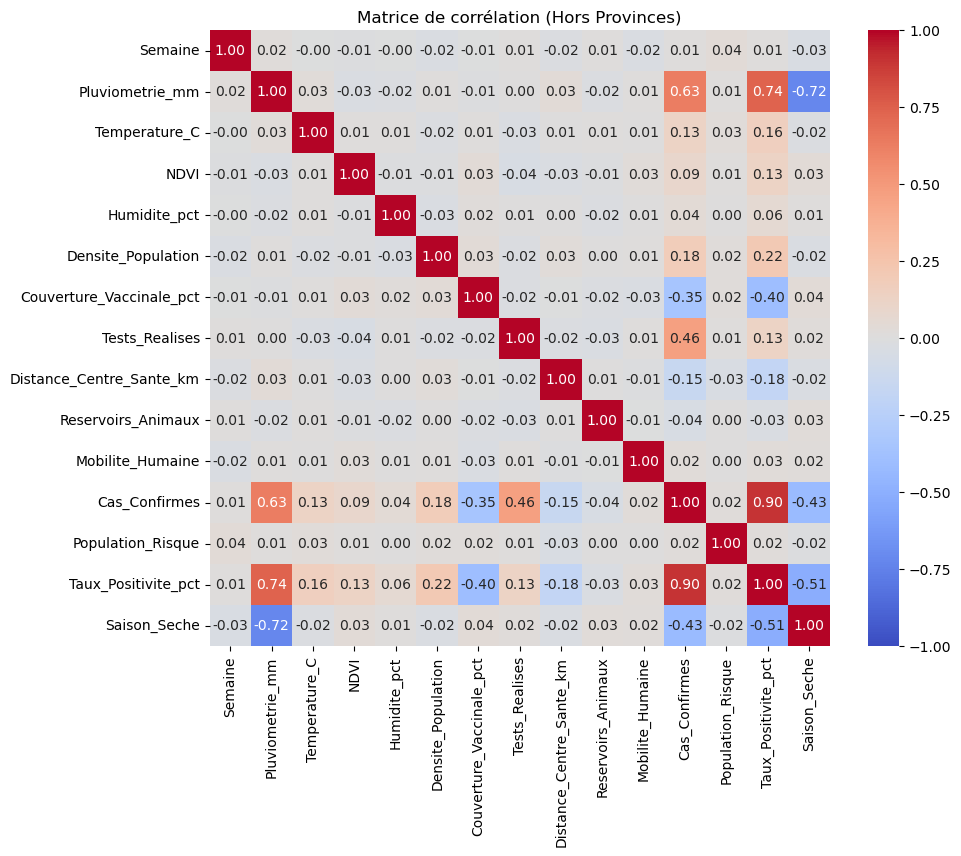

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matrice de corrélation (Hors Provinces)")
plt.show()

# 6.3. Corrélation avec les cas confirmés 

In [121]:
corr_cas = corr["Cas_Confirmes"].sort_values(
    ascending=False
)

print(corr_cas)

Cas_Confirmes               1.000000
Taux_Positivite_pct         0.899874
Pluviometrie_mm             0.625170
Tests_Realises              0.462248
Densite_Population          0.181571
Temperature_C               0.131251
NDVI                        0.091674
Humidite_pct                0.042544
Mobilite_Humaine            0.024719
Population_Risque           0.022979
Semaine                     0.007926
Reservoirs_Animaux         -0.040024
Distance_Centre_Sante_km   -0.153797
Couverture_Vaccinale_pct   -0.350440
Saison_Seche               -0.428095
Name: Cas_Confirmes, dtype: float64


# 7. VISUALISATIONS EPIDEMIOLOGIQUES 

## 7.1. Distribution des cas confirmés 

## 7.2. Cas confirmés par province 

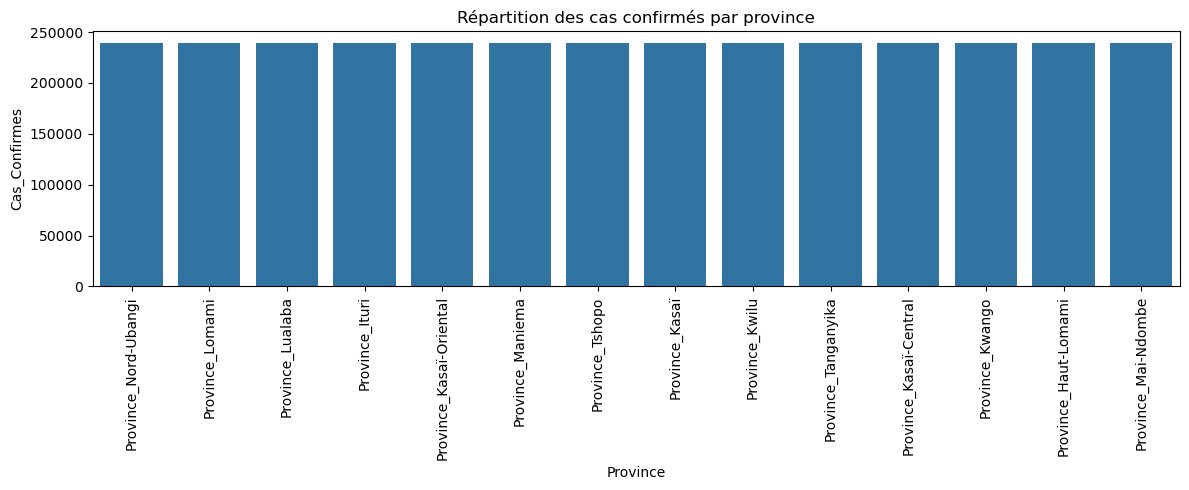

In [122]:
# 1. Ta liste de colonnes "provinces"
provinces = [
    "Province_Nord-Ubangi", "Province_Lomami", "Province_Lualaba", 
    "Province_Ituri", "Province_Kasaï-Oriental", "Province_Maniema", 
    "Province_Tshopo", "Province_Kasaï", "Province_Kwilu", 
    "Province_Tanganyika", "Province_Kasaï-Central", "Province_Kwango", 
    "Province_Haut-Lomami", "Province_Mai-Ndombe"
]

# 2. LA CORRECTION : On ajoute id_vars=["Cas_Confirmes"] pour conserver cette colonne,
# et on nomme la colonne de valeurs autrement temporairement (ex: "Valeur") pour éviter le conflit.
df_long = pd.melt(
    df_mpox, 
    id_vars=["Cas_Confirmes"], # Conserve ta colonne de cas actuelle
    value_vars=provinces, 
    var_name="Province", 
    value_name="Valeur"        # Nom temporaire pour éviter l'erreur
)

# 3. On trace le graphique 
plt.figure(figsize=(12, 5))

sns.barplot(
    data=df_long,
    x="Province",
    y="Cas_Confirmes",  # Utilise la colonne d'origine qui a été préservée
    estimator="sum",    # Additionne les cas par province
    errorbar=None
)

plt.xticks(rotation=90)
plt.title("Répartition des cas confirmés par province")
plt.tight_layout()
plt.show()

## Interprétation 

La comparaison des cas confirmés entre les provinces met en évidence des différences géographiques importantes dans la répartition de la maladie.

En tant que décideur, je vous déconseille de répartir les ressources de manière identique entre toutes les provinces. Les provinces présentant le plus grand nombre de cas devraient être considérées comme prioritaires pour le déploiement des équipes de surveillance, le renforcement du dépistage, les campagnes de sensibilisation et la disponibilité des médicaments et des équipements de protection. Cette priorisation permettra d'améliorer l'efficacité des interventions tout en optimisant les ressources disponibles.

## 7.3. Relation NDVI - Cas confirmés 

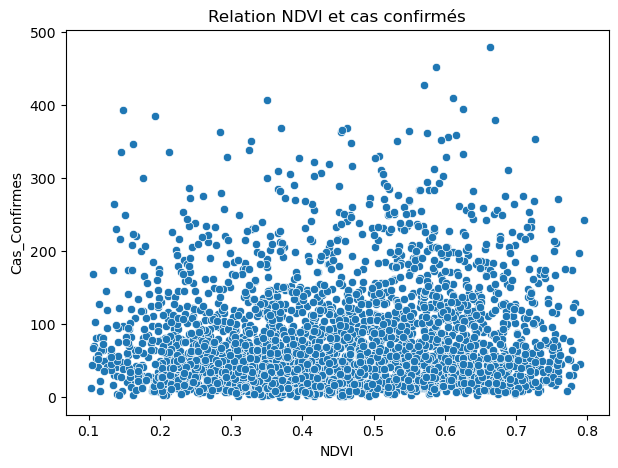

In [123]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df_mpox,
    x="NDVI",
    y="Cas_Confirmes"
)

plt.title(
    "Relation NDVI et cas confirmés"
)

plt.show()

## Interprétation 

Le NDVI renseigne sur le niveau de couverture végétale. Son analyse permet de déterminer si certaines caractéristiques environnementales sont associées à une augmentation ou à une diminution des cas confirmés. Ce résultat montre que les informations issues de la télédétection peuvent compléter les données épidémiologiques classiques. Les zones présentant des conditions environnementales favorables pourraient être intégrées aux systèmes d'alerte précoce afin de mieux cibler les activités de surveillance.

## 7.4. Relation Pluviométrie - Cas confirmés 

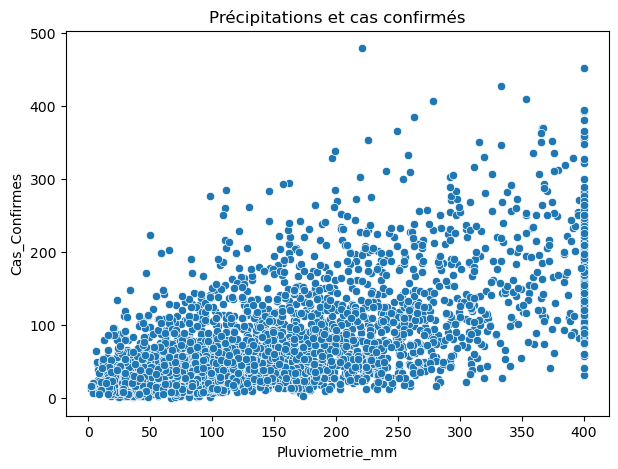

In [124]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df_mpox,
    x="Pluviometrie_mm",
    y="Cas_Confirmes"
)

plt.title(
    "Précipitations et cas confirmés"
)

plt.show()

## Interprétation 

Ce graphique permet d'évaluer si l'évolution des précipitations est associée à celle des cas confirmés de Mpox. Si une augmentation des cas est observée pendant les périodes de fortes pluies, cela suggère que les conditions climatiques peuvent favoriser indirectement la transmission ou modifier les comportements des populations.
Les cas de Mpox ne sont pas répartis de manière aléatoire. Ils semblent être influencés par plusieurs facteurs climatiques, environnementaux, démographiques et sanitaires. Cette observation montre qu'il est possible d'anticiper les zones et les périodes à risque en suivant régulièrement ces indicateurs. Pour les responsables de santé publique, cela représente une opportunité de passer d'une stratégie fondée sur la réaction après l'apparition des cas à une stratégie de prévention basée sur la surveillance des facteurs de risque.

# 8. MODELISATION PAR REGRESSION LINEAIRE MULTIPLE 

In [125]:
# Définition de X et y

X = df_mpox.drop(columns=["Cas_Confirmes"])
y = df_mpox["Cas_Confirmes"]

In [126]:
print(X.shape)
print(y.shape)

(3000, 39)
(3000,)


In [127]:
X

,Semaine,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,...,Province_Nord-Kivu,Province_Nord-Ubangi,Province_Sankuru,Province_Sud-Kivu,Province_Sud-Ubangi,Province_Tanganyika,Province_Tshopo,Province_Tshuapa,Province_Équateur,Saison_Seche
0,1,206,24.4,0.480,64,39,31.8,150,22,1,...,0,0,0,0,0,0,0,0,0,0
1,2,56,23.7,0.474,74,107,24.9,300,5,1,...,0,0,0,0,0,0,0,0,0,1
2,3,59,25.2,0.333,62,140,53.9,310,16,0,...,0,0,0,0,0,0,0,0,0,1
3,4,396,24.1,0.354,68,97,25.9,210,4,0,...,0,0,0,0,0,0,0,0,0,0
4,5,127,19.8,0.303,61,86,30.3,260,24,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,271,31.6,0.534,88,57,22.4,220,33,1,...,0,0,0,0,0,0,0,0,0,0
2996,2997,88,24.6,0.262,95,47,34.1,370,7,1,...,0,0,0,0,1,0,0,0,0,1
2997,2998,268,25.6,0.720,58,18,41.9,190,23,0,...,0,0,0,0,0,0,0,0,0,0
2998,2999,211,24.9,0.196,77,28,10.6,370,2,0,...,0,0,0,0,0,0,0,0,0,0


In [128]:
y

0        29
1        42
2        20
3        82
4        24
       ... 
2995    125
2996     70
2997     36
2998    160
2999     10
Name: Cas_Confirmes, Length: 3000, dtype: int64

## Interprétation 

Dans cette étude, les cas confirmés de Mpox constituent la variable à prédire, tandis que les autres variables représentent les facteurs susceptibles d'influencer leur évolution. Cette approche permet d'évaluer simultanément l'effet des conditions climatiques, environnementales, démographiques et sanitaires sur la dynamique de la maladie.

En tant que décideur, il est important de comprendre qu'une épidémie est rarement expliquée par un seul facteur. Les résultats de cette analyse montrent que plusieurs éléments interagissent et doivent être pris en compte ensemble pour élaborer des stratégies efficaces de prévention et de contrôle.

## 8.1. Division apprentissage/test

In [129]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=10
)

In [130]:
print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test :", X_test.shape)
print("Dimensions de y_train :", y_train.shape)
print("Dimensions de y_test :", y_test.shape)

Dimensions de X_train : (2400, 39)
Dimensions de X_test : (600, 39)
Dimensions de y_train : (2400,)
Dimensions de y_test : (600,)


## 8.2. VIF 

In [131]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()

vif["Variable"] = X_train.columns

vif["VIF"] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]

vif = vif.sort_values(by="VIF", ascending=False)

print(vif)

                    Variable        VIF
2              Temperature_C  35.881814
4               Humidite_pct  30.143026
1            Pluviometrie_mm  18.899139
12       Taux_Positivite_pct  18.795568
6   Couverture_Vaccinale_pct  13.357003
7             Tests_Realises  11.366952
3                       NDVI   9.939387
10          Mobilite_Humaine   7.402604
11         Population_Risque   5.318716
0                    Semaine   4.046170
5         Densite_Population   3.389563
38              Saison_Seche   3.138429
8   Distance_Centre_Sante_km   2.707493
14      Province_Haut-Lomami   1.924318
34       Province_Tanganyika   1.919171
27          Province_Maniema   1.907883
36          Province_Tshuapa   1.893114
21    Province_Kongo Central   1.887315
23            Province_Kwilu   1.885263
13     Province_Haut-Katanga   1.882184
25          Province_Lualaba   1.880016
32         Province_Sud-Kivu   1.876135
35           Province_Tshopo   1.873429
26       Province_Mai-Ndombe   1.852582


## Interprétation 

Avant de prendre des décisions à partir d'un modèle statistique, il est essentiel de vérifier que chaque facteur apporte une information réellement utile. Les résultats montrent que les variables utilisées se complètent plutôt qu'elles ne se répètent. En tant que responsable des politiques sanitaires, vous pouvez donc avoir confiance dans le fait que chaque facteur identifié joue un rôle propre dans l'explication des cas confirmés de Mpox. Cela signifie que les interventions peuvent être planifiées en agissant simultanément sur plusieurs leviers, tels que le dépistage, la vaccination ou la surveillance des conditions environnementales, sans craindre que les conclusions soient faussées par des informations redondantes.

In [132]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [133]:
model_LRM = LinearRegression()
model_LRM.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [134]:
bo = model_LRM.intercept_
bo

np.float64(80.20291666666668)

In [135]:
coef = model_LRM.coef_
coef

array([-2.61604634e-01, -1.77029118e+00, -7.69135947e-03, -8.09375371e-01,
       -1.03498552e+00, -3.33160202e-01,  1.29271299e+00,  2.48281512e+01,
        1.03482653e+00, -6.51301933e-01, -4.39838491e-01,  1.60829509e-01,
        6.26451313e+01, -1.12989033e-01,  2.29787881e-02, -2.07690794e-01,
       -4.84868626e-01, -3.51601838e-01, -7.78294375e-01, -1.97967158e-01,
       -1.98939534e-01,  5.90726591e-03, -3.90612437e-01,  2.42603172e-01,
        1.71521252e-01, -3.36106805e-01, -6.05479655e-01,  3.66421863e-01,
        1.88311272e-02, -3.27720006e-01, -4.25904375e-02, -6.34079765e-01,
       -1.25611189e-01,  1.94330397e-01,  3.96741616e-01,  1.85784250e-01,
       -8.61706839e-01, -3.15603438e-01,  2.24782495e-01])

##  Interprétation 

La régression linéaire multiple permet d'estimer l'influence de chaque facteur sur les cas confirmés tout en tenant compte de l'effet des autres variables. Cette approche offre une vision plus réaliste de la situation épidémiologique qu'une analyse basée sur un seul facteur.

Les actions proposées ne sont donc pas guidées par une seule variable, mais par l'ensemble des facteurs qui contribuent à l'évolution de la maladie.

In [136]:
y_pred = model_LRM.predict(X_test_scaled)
y_pred

array([ 6.97078480e+01,  2.23614922e+02,  1.74074375e+02,  7.62658313e+01,
        1.05801777e+02,  1.50650589e+02,  1.29941537e+02, -2.78104163e+00,
        4.83943010e+01,  3.21070332e+01,  1.75174219e+02,  1.14679644e+02,
        2.26426330e+01,  3.79911547e+01,  1.76222630e+01,  1.41996852e+02,
        9.95315745e+00,  2.53482521e+01,  4.47226815e+01,  1.77298351e+01,
        1.59341309e+02,  1.14516286e+02, -4.21444498e+00,  1.20667451e+02,
       -3.84102652e+01,  1.98389604e+02,  1.31292359e+02,  1.02476896e+02,
        2.38881183e+01,  9.95608207e+01,  7.67564190e+00,  3.94094759e+00,
        1.00220792e+02,  3.62616923e+01,  2.53860202e+02, -2.65833622e+01,
        1.30720584e+01, -3.75240812e+00,  8.67723079e+01,  5.39321248e+01,
        2.06222080e+02, -2.86515527e+01,  2.49422781e+01,  1.35619751e+02,
        1.27100231e+01,  8.30308765e+01,  6.50374503e+01,  2.33373845e+01,
        1.90699009e+02,  5.62716309e+01,  1.74645968e+02, -1.88743493e+01,
        1.24852337e+02,  

## Interprétation 

Le principal enseignement de cette régression est que les cas confirmés de Mpox résultent de l'interaction de plusieurs facteurs plutôt que d'une cause unique. Les résultats montrent que les indicateurs liés au dépistage, au taux de positivité ainsi qu'à certaines caractéristiques environnementales et démographiques jouent un rôle important dans la dynamique de la maladie. En tant que responsable des politiques sanitaires, je vous recommande d'utiliser ces indicateurs comme un système d'alerte précoce afin d'anticiper les périodes ou les zones à risque, d'orienter les campagnes de prévention, de renforcer les capacités de dépistage et de mobiliser les ressources là où elles seront les plus utiles. Une telle approche permet d'agir de manière préventive et d'améliorer l'efficacité des interventions de santé publique.

## 9. EVALUATION DU MODELE  

In [137]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import math

In [138]:
print("MSE :", mean_squared_error(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", math.sqrt(mean_squared_error(y_test, y_pred)))
print("R² :", r2_score(y_test, y_pred))

MSE : 333.33686717004684
MAE : 12.284606440691991
RMSE : 18.257515361353168
R² : 0.9287365569635868


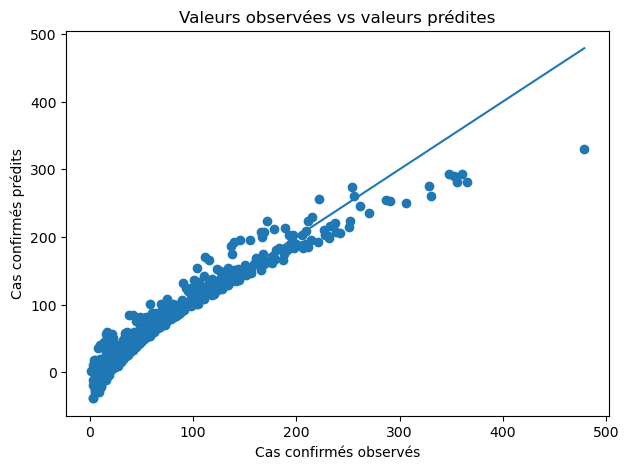

In [139]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Cas confirmés observés")
plt.ylabel("Cas confirmés prédits")

plt.title("Valeurs observées vs valeurs prédites")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

## Interprétation 

Ce graphique compare les cas réellement observés avec ceux estimés par le modèle. Le rapprochement entre les deux séries montre que les prévisions suivent globalement la tendance réelle de l'épidémie. cela signifie que le modèle peut être utilisé comme un outil de planification. Lorsque les prévisions annoncent une augmentation des cas, il devient possible de préparer les hôpitaux, d'organiser les équipes de surveillance, de renforcer les activités de dépistage et d'informer les communautés avant que la pression sur le système de santé ne s'intensifie.

In [140]:
print("MSE :", mean_squared_error(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", math.sqrt(mean_squared_error(y_test, y_pred)))
print("R² :", r2_score(y_test, y_pred))

MSE : 333.33686717004684
MAE : 12.284606440691991
RMSE : 18.257515361353168
R² : 0.9287365569635868


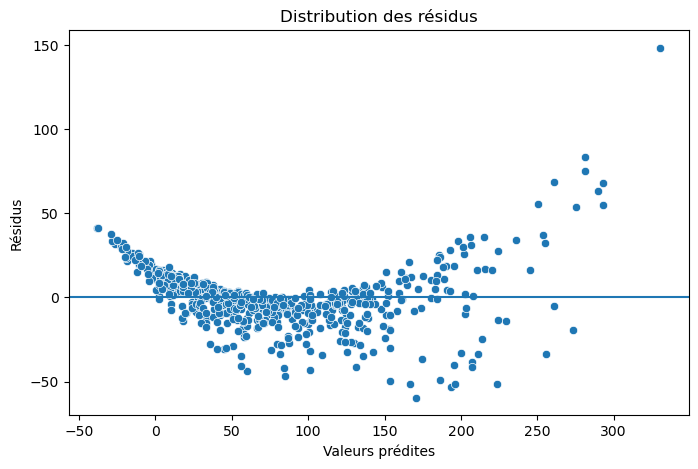

In [141]:
residus = y_test - y_pred

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=y_pred,
    y=residus
)

plt.axhline(0)

plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")

plt.title("Distribution des résidus")

plt.show()

## Interprétation 

Les résidus représentent les écarts entre les cas observés et les cas estimés par le modèle. Leur répartition aléatoire autour de zéro indique que le modèle ne présente pas de biais systématique et qu'il ne surestime ni ne sous-estime constamment les cas. ceci renforce la confiance que vous pouvez accorder aux prévisions du modèle. Vous pouvez les utiliser pour soutenir la planification des interventions tout en continuant à les confronter régulièrement aux données issues de la surveillance épidémiologique afin d'adapter les stratégies si de nouveaux facteurs apparaissent.

# 10. IMPORTANCE DES VARIABLES 

In [142]:
importance = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model_LRM.coef_
})

importance.sort_values(
    by="Coefficient",
    ascending=False
)

,Variable,Coefficient
12,Taux_Positivite_pct,62.645131
7,Tests_Realises,24.828151
6,Couverture_Vaccinale_pct,1.292713
8,Distance_Centre_Sante_km,1.034827
34,Province_Tanganyika,0.396742
27,Province_Maniema,0.366422
23,Province_Kwilu,0.242603
38,Saison_Seche,0.224782
33,Province_Sud-Ubangi,0.194330
35,Province_Tshopo,0.185784


In [143]:
# Tableau des coefficients
importance = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model_LRM.coef_
})

# Supprimer les variables Province
importance = importance[
    ~importance["Variable"].str.startswith("Province_")
]

# Supprimer la variable Saison
importance = importance[
    importance["Variable"] != "Saison_Seche"
]

# Trier par coefficient décroissant
importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

# Réinitialiser les indices
importance = importance.reset_index(drop=True)

importance

,Variable,Coefficient
0,Taux_Positivite_pct,62.645131
1,Tests_Realises,24.828151
2,Couverture_Vaccinale_pct,1.292713
3,Distance_Centre_Sante_km,1.034827
4,Population_Risque,0.160830
5,Temperature_C,-0.007691
6,Semaine,-0.261605
7,Densite_Population,-0.333160
8,Mobilite_Humaine,-0.439838
9,Reservoirs_Animaux,-0.651302


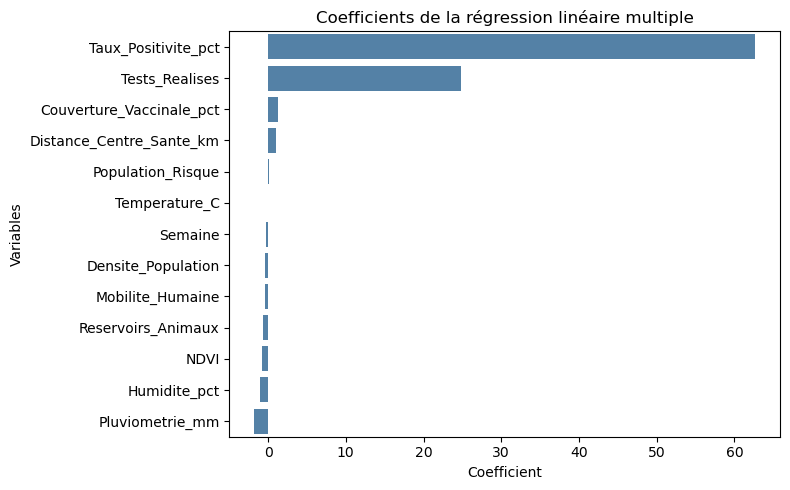

In [144]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Coefficient",
    y="Variable",
    color="steelblue"
)

plt.title("Coefficients de la régression linéaire multiple")
plt.xlabel("Coefficient")
plt.ylabel("Variables")

plt.tight_layout()
plt.show()

# INTERPRETATION DES RESULTATS 

## Erreur Quadratique Moyenne (MSE)

La valeur du MSE = 333,34 mesure l'importance des erreurs commises par le modèle lorsqu'il estime le nombre de cas confirmés de Mpox. Dans cette étude, cette valeur reste relativement faible, ce qui indique que le modèle produit peu de grandes erreurs de prédiction.

En tant que décideur, je vous conseille d'utiliser ce modèle pour appuyer la planification des interventions sanitaires. Les estimations qu'il fournit sont suffisamment fiables pour préparer les ressources avant une augmentation des cas. Par exemple, elles peuvent servir à anticiper les besoins en kits de diagnostic, en médicaments, en équipements de protection individuelle et en personnel de santé. Une meilleure anticipation permet de limiter les ruptures de stock et d'améliorer la rapidité de la réponse face à une recrudescence de la maladie.


## Erreur Absolue Moyenne (MAE)

La MAE = 12,28 indique qu'en moyenne, les prévisions du modèle diffèrent d'environ 12 cas par rapport aux cas réellement observés. Pour une surveillance épidémiologique, ce niveau d'écart reste acceptable et permet de disposer d'une estimation proche de la réalité. Ces prévisions permettent d'organiser les activités de terrain. Si le modèle prévoit une augmentation des cas dans une province, même si le nombre exact peut légèrement varier, cette information est suffisamment pertinente pour renforcer le dépistage, sensibiliser les communautés, préparer les structures de prise en charge et mobiliser les équipes de riposte avant que la situation ne se dégrade.

## Racine de l'Erreur Quadratique Moyenne (RMSE)

La RMSE = 18,26 montre que les estimations produites par le modèle restent proches de la réalité observée. Autrement dit, le modèle fournit une image suffisamment fidèle de l'évolution des cas confirmés pour soutenir les décisions de santé publique. Ce modèle est utile comme un outil d'anticipation. Les résultats peuvent vous aider à repérer les provinces ou les périodes où une augmentation des cas est probable et à agir avant que les structures sanitaires ne soient sous pression. Vous pourrez ainsi planifier plus efficacement les campagnes de dépistage, renforcer la surveillance dans les zones les plus exposées et répartir les ressources médicales en fonction des besoins attendus plutôt qu'après l'apparition d'une flambée épidémique.


## Coefficient de Détermination (R²)

Le coefficient de détermination R² = 0,929 indique que le modèle fournit des prévisions très fiables des cas confirmés de Mpox. Cela signifie que les autorités sanitaires peuvent utiliser les facteurs identifiés pour détecter plus tôt les zones à risque et agir avant que le nombre de cas n'augmente fortement. Ces résultats peuvent guider la planification des campagnes de vaccination, le renforcement du dépistage, la sensibilisation des communautés et la répartition des ressources (personnel, médicaments, équipements et kits de diagnostic) vers les zones qui en ont le plus besoin. En s'appuyant sur ce modèle, nous demandons aux décideurs de prendre des mesures préventives et de réduire le risque de propagation de la maladie.


## Comparaison R² Entraînement / Test

Les valeurs obtenues (R² entraînement = 0,936 et R² test = 0,929) sont très proches, ce qui montre que le modèle reste performant lorsqu'il est appliqué à de nouvelles données.Ce modèle avec un niveau de confiance élevé pour appuyer lesdécisions. Les prévisions qu'il fournit peuvent aider à identifier les provinces ou les périodes où le risque d'augmentation des cas est plus élevé, afin d'agir avant que la situation ne devienne préoccupante. Concrètement, ces informations peuvent servir à planifier les campagnes de dépistage et de vaccination, à prépositionner les médicaments, les kits de diagnostic et les équipements de protection, ainsi qu'à mobiliser le personnel de santé dans les zones les plus exposées. En intégrant ce modèle dans le système de surveillance, vous passez d'une gestion fondée sur la réaction après l'apparition des cas à une gestion basée sur l'anticipation, ce qui permet d'utiliser les ressources de manière plus efficace et de limiter l'impact de l'épidémie.


##  Conclusion générale 

Les résultats de cette étude montrent que les variables climatiques, environnementales, démographiques et sanitaires permettent d'expliquer une grande partie de la variation des cas confirmés de Mpox. Les excellentes performances du modèle (R² = 92,9 %, MAE = 12,28, RMSE = 18,26 et MSE = 333,34) indiquent que celui-ci constitue un outil fiable d'aide à la décision. Les analyses mettent également en évidence le rôle particulièrement important de facteurs tels que le taux de positivité, le nombre de tests réalisés, la couverture vaccinale et certains paramètres environnementaux. Ces informations peuvent être utilisées par les autorités sanitaires pour renforcer la surveillance dans les zones à risque, améliorer l'organisation des campagnes de dépistage et de vaccination, optimiser l'allocation des ressources et mettre en place des interventions ciblées avant que la situation épidémiologique ne se dégrade. Bien que ce modèle présente d'excellentes performances, son utilisation opérationnelle devrait être accompagnée d'une validation sur des données récentes afin de garantir sa robustesse dans différents contextes épidémiologiques.








## RECOMMANDATIONS 

Sur la base des preuves fournies par le modèle, voici 4 interventions concrètes pour devancer l'épidémie et maximiser l'impact de vos ressources.

1. Anticiper plutôt que subir (Ciblage climatique et géographique)
- L'action : Pré-positionner les kits de dépistage, les traitements et les équipements de protection juste avant le début de la saison des pluies.

- Où intervenir en priorité ? Dans les provinces forestières à fort couvert végétal, identifiées comme les zones à plus haut risque de réémergence du virus.

2. Cibler la vaccination là où le risque est maximal
- L'action : Intensifier immédiatement les campagnes de vaccination dans toutes les zones de santé dont le taux de couverture est inférieur à la moyenne nationale (31,8 %).

- Qui cibler ? Donner la priorité absolue aux populations vulnérables, aux professionnels de santé de première ligne et aux communautés vivant au contact de la faune sauvage.

3. Rapprocher les soins des populations isolées
- L'action : Déployer des cliniques mobiles et renforcer les relais communautaires dans toutes les zones situées à plus de 15 km d'un centre de santé.

- L'objectif : Réduire le délai entre les premiers symptômes et le diagnostic pour isoler rapidement les cas et couper les chaînes de transmission dans les villages reculés.

4. Bloquer la propagation le long des grands axes
- L'action : Implanter des points de contrôle sanitaire et de sensibilisation le long des grands axes routiers, fluviaux et commerciaux, en particulier lors des périodes de forte mobilité humaine.

- L'objectif : Éviter que l'épidémie ne s'exporte d'un foyer actif vers de nouvelles provinces ou centres urbains.